In [1]:
import xsimlab as xs
import pandas as pd
import numpy as np
import pathlib

import xsimlab.dot as dot
import vmlab
from vmlab.models import *

## Creando la funcion con Debugg para el Environment

In [6]:
from vmlab.processes.environment import Environment

@xs.process
class DebugEnvironment(Environment):
    """
    Custom environment process to debug paleo climate data loading
    """
    
    # Add a conversion factor for radiation units
    radiation_conversion_factor = xs.variable(
        intent='in',
        default=1.0,
        description='Factor to convert paleo radiation units to model units (J/cm²/h)'
    )
    
    def initialize(self):
        # Call the parent initialization first
        super().initialize()
        
        print("🔍 === PALEO CLIMATE DEBUG INFORMATION ===")
        print(f"📁 Weather file loaded: {self.weather_file}")
        print(f"📊 Data shape: {self.weather_hourly_df.shape}")
        print(f"📅 Date range: {self.weather_hourly_df.index.min()} to {self.weather_hourly_df.index.max()}")
        
        # Print statistics for each variable
        print("\n🌡️ TEMPERATURE (TM):")
        print(f"   Min: {self.weather_hourly_df['TM'].min():.1f}°C")
        print(f"   Max: {self.weather_hourly_df['TM'].max():.1f}°C") 
        print(f"   Mean: {self.weather_hourly_df['TM'].mean():.1f}°C")
        
        print("\n☀️ RADIATION (GR) - BEFORE CONVERSION:")
        print(f"   Min: {self.weather_hourly_df['GR'].min():.1f}")
        print(f"   Max: {self.weather_hourly_df['GR'].max():.1f}")
        print(f"   Mean: {self.weather_hourly_df['GR'].mean():.1f}")
        
        # Apply radiation conversion if needed
        if self.radiation_conversion_factor != 1.0:
            print(f"\n🔄 Applying radiation conversion factor: {self.radiation_conversion_factor}")
            self.weather_hourly_df['GR'] = self.weather_hourly_df['GR'] * self.radiation_conversion_factor
            self.weather_daily_df['GR'] = self.weather_daily_df['GR'] * self.radiation_conversion_factor
            
            print("☀️ RADIATION (GR) - AFTER CONVERSION:")
            print(f"   Min: {self.weather_hourly_df['GR'].min():.1f} J/cm²/h")
            print(f"   Max: {self.weather_hourly_df['GR'].max():.1f} J/cm²/h")
            print(f"   Mean: {self.weather_hourly_df['GR'].mean():.1f} J/cm²/h")
        
        print("\n💧 HUMIDITY (RH):")
        print(f"   Min: {self.weather_hourly_df['RH'].min():.1f}%")
        print(f"   Max: {self.weather_hourly_df['RH'].max():.1f}%")
        print(f"   Mean: {self.weather_hourly_df['RH'].mean():.1f}%")
        
        # Check for potential unit issues
        self._check_unit_issues()
        
    def _check_unit_issues(self):
        """Check for common unit conversion problems"""
        print("\n⚠️ UNIT CHECK:")
        
        # Check temperature (should be reasonable for Earth)
        if self.weather_hourly_df['TM'].min() < -50 or self.weather_hourly_df['TM'].max() > 60:
            print("   ❌ Temperature range seems unusual for Earth conditions")
        else:
            print("   ✅ Temperature range looks reasonable")
            
        # Check radiation (typical range for J/cm²/h is ~0-4000)
        current_max_rad = self.weather_hourly_df['GR'].max()
        if current_max_rad > 10000:
            print(f"   ❌ Radiation too high ({current_max_rad:.1f} J/cm²/h)")
            print("      Expected range: 0-4000 J/cm²/h")
            print("      Your data might be in MJ/m²/day or other units")
            print("      Try radiation_conversion_factor = 0.01 or 0.001")
        elif current_max_rad > 4000:
            print(f"   ⚠️ Radiation somewhat high ({current_max_rad:.1f} J/cm²/h)")
            print("      Try radiation_conversion_factor = 0.1")
        else:
            print("   ✅ Radiation range looks reasonable")
            
        # Check humidity (should be 0-100%)
        if self.weather_hourly_df['RH'].min() < 0 or self.weather_hourly_df['RH'].max() > 100:
            print("   ❌ Humidity outside 0-100% range")
        else:
            print("   ✅ Humidity range looks reasonable")
    
    @xs.runtime(args=('step', 'step_start', 'step_end', 'step_delta'))
    def run_step(self, step, step_start, step_end, step_delta):
        # Call parent method
        super().run_step(step, step_start, step_end, step_delta)
        
        # Print first 3 steps to verify data flow
        if step < 3:
            print(f"📅 Step {step} ({step_start}): TM={self.TM_day:.1f}°C, GR={self.GR_day:.1f} J/cm²/h, RH={self.RH_day:.1f}%")

## Reemplazamos el processo con la Class que creamos Arriba

In [4]:
# Create debug model with custom environment but keeping your harvest
debug_model = vmango.update_processes({'environment': DebugEnvironment}).drop_processes('geometry')
xs.process_info(debug_model.environment)

<DebugEnvironment  (xsimlab process)>
Variables:
    parameter_file_path             [in]
    parameters                     [out]
    hour                           [out] ('hour',) 
    weather_file                    [in] path to file with weather ...
    TM                             [out] ('hour',) hourly temperatu...
    TM_day                         [out] daily mean temperature of ...
    GR                             [out] ('hour',) hourly global ra...
    GR_day                         [out] mean global radiations of ...
    RH                             [out] ('hour',) hourly relative ...
    RH_day                         [out] mean relative humidity of ...
    radiation_conversion_factor     [in] Factor to convert paleo ra...
Simulation stages:
    initialize
    run_step


## Configurando el modelo y activando el valor de conversion 'environment__radiation_conversion_factor' 

In [10]:
def compare_climate_effects():
    """Compare model behavior with default vs paleo climate data"""
    
    # Test 1: Default climate (baseline)
    print("="*60)
    print("🎯 TEST 1: DEFAULT CLIMATE (vmango.toml)")
    print("="*60)
    
    setup_default = vmlab.create_setup(
        model=debug_model,
        start_date='2003-06-01',
        end_date='2003-06-05',  # Very short test period
        setup_toml='vmango.toml',  # Default config
        input_vars={
            'environment__radiation_conversion_factor': 1.0  # No conversion
        },
        output_vars={
            'environment': {
                'TM_day': 'day', 
                'GR_day': 'day',
                'RH_day': 'day'},
            'photosynthesis': {
                'photo': 'day',
                'photo_shaded': 'day',
                'photo_sunlit': 'day'
                },
            'phenology': {'fruit_growth_tts': 'day'}
        }
    )
    
    ds_default = vmlab.run(setup_default, debug_model)
    
    # Test 2: Paleo climate  
    print("\n" + "="*60)
    print("🎯 TEST 2: PALEO CLIMATE (vmango_fosil.toml)") 
    print("="*60)
    
    # Try different conversion factors to find the right one
    conversion_factors = [1.0, 0.1, 0.01, 0.001]
    
    results = []
    for factor in conversion_factors:
        print(f"\n--- Testing conversion factor: {factor} ---")
        
        setup_paleo = vmlab.create_setup(
            model=debug_model,
            start_date='2003-06-01',
            end_date='2003-06-05',
            setup_toml='vmango_fosil.toml',  # Your paleo config
            input_vars={
                'environment__radiation_conversion_factor': factor
            },
            output_vars={
                'environment': {
                    'TM_day': 'day', 
                    'GR_day': 'day',
                    'RH_day': 'day'},
                'photosynthesis': {
                    'photo': 'day',
                    'photo_shaded': 'day',
                    'photo_sunlit': 'day'
                    },
                'phenology': {'fruit_growth_tts': 'day'}
            }
        )
        
        ds_paleo = vmlab.run(setup_paleo, debug_model)
        
        # Store results
        avg_rad = ds_paleo.environment__GR_day.mean().values
        avg_photo = ds_paleo.photosynthesis__photo.mean().values
        results.append((factor, avg_rad, avg_photo))
        
        print(f"   Avg Radiation: {avg_rad:.1f} J/cm²/h")
        print(f"   Avg Photosynthesis: {avg_photo:.3f}")
    
    return ds_default, results

# Run the comparison
ds_default, paleo_results = compare_climate_effects()

🎯 TEST 1: DEFAULT CLIMATE (vmango.toml)


             0% | initialize 

🔍 === PALEO CLIMATE DEBUG INFORMATION ===
📁 Weather file loaded: 
📊 Data shape: (52356, 3)
📅 Date range: 2002-01-01 01:00:00 to 2008-01-02 00:00:00

🌡️ TEMPERATURE (TM):
   Min: 12.8°C
   Max: 34.1°C
   Mean: 22.9°C

☀️ RADIATION (GR) - BEFORE CONVERSION:
   Min: 0.0
   Max: 448.0
   Mean: 82.3

💧 HUMIDITY (RH):
   Min: 0.0%
   Max: 127.0%
   Mean: 71.3%

⚠️ UNIT CHECK:
   ✅ Temperature range looks reasonable
   ✅ Radiation range looks reasonable
   ❌ Humidity outside 0-100% range
📅 Step 0 (2003-06-01T00:00:00.000000000): TM=21.4°C, GR=57.1 J/cm²/h, RH=75.7%
📅 Step 1 (2003-06-02T00:00:00.000000000): TM=21.9°C, GR=65.2 J/cm²/h, RH=78.8%
📅 Step 2 (2003-06-03T00:00:00.000000000): TM=21.9°C, GR=69.8 J/cm²/h, RH=75.3%


c:\Users\jcarlos.vargas\AppData\Local\anaconda3\envs\vmango-lab\lib\site-packages\xarray\core\utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(



🎯 TEST 2: PALEO CLIMATE (vmango_fosil.toml)

--- Testing conversion factor: 1.0 ---


...

c:\Users\jcarlos.vargas\AppData\Local\anaconda3\envs\vmango-lab\lib\site-packages\xarray\core\utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


   Avg Radiation: 7.9 J/cm²/h
   Avg Photosynthesis: 0.000

--- Testing conversion factor: 0.001 ---


             0% | initialize 

🔍 === PALEO CLIMATE DEBUG INFORMATION ===
📁 Weather file loaded: 
📊 Data shape: (52560, 3)
📅 Date range: 2002-01-01 00:00:00 to 2007-12-30 23:00:00

🌡️ TEMPERATURE (TM):
   Min: 15.0°C
   Max: 28.0°C
   Mean: 21.5°C

☀️ RADIATION (GR) - BEFORE CONVERSION:
   Min: 0.0
   Max: 3452.0
   Mean: 833.7

🔄 Applying radiation conversion factor: 0.001
☀️ RADIATION (GR) - AFTER CONVERSION:
   Min: 0.0 J/cm²/h
   Max: 3.5 J/cm²/h
   Mean: 0.8 J/cm²/h

💧 HUMIDITY (RH):
   Min: 60.0%
   Max: 95.0%
   Mean: 78.0%

⚠️ UNIT CHECK:
   ✅ Temperature range looks reasonable
   ✅ Radiation range looks reasonable
   ✅ Humidity range looks reasonable
📅 Step 0 (2003-06-01T00:00:00.000000000): TM=23.0°C, GR=0.8 J/cm²/h, RH=77.2%
📅 Step 1 (2003-06-02T00:00:00.000000000): TM=23.7°C, GR=0.8 J/cm²/h, RH=77.7%
📅 Step 2 (2003-06-03T00:00:00.000000000): TM=23.2°C, GR=0.8 J/cm²/h, RH=78.6%
   Avg Radiation: 0.8 J/cm²/h
   Avg Photosynthesis: 0.000


c:\Users\jcarlos.vargas\AppData\Local\anaconda3\envs\vmango-lab\lib\site-packages\xarray\core\utils.py:494: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  warnings.warn(


## Analizando los resultados 


📊 COMPARISON RESULTS

📍 DEFAULT CLIMATE:
   Average Radiation: 62.1 J/cm²/h
   Average Photosynthesis: 0.000

📍 PALEO CLIMATE RESULTS:
   Factor | Radiation | Photosynthesis | Status
   --------------------------------------------------
    1.000 |    788.8   |         0.000  | ❌ NEEDS ADJUSTMENT
    0.100 |     78.9   |         0.000  | ❌ NEEDS ADJUSTMENT
    0.010 |      7.9   |         0.000  | ❌ NEEDS ADJUSTMENT
    0.001 |      0.8   |         0.000  | ❌ NEEDS ADJUSTMENT


C:\Users\jcarlos.vargas\AppData\Local\Temp\ipykernel_7920\288533321.py:25: RuntimeWarning: invalid value encountered in true_divide
  status = "✅ GOOD" if 0.5 <= photo/default_photo <= 2.0 else "❌ NEEDS ADJUSTMENT"


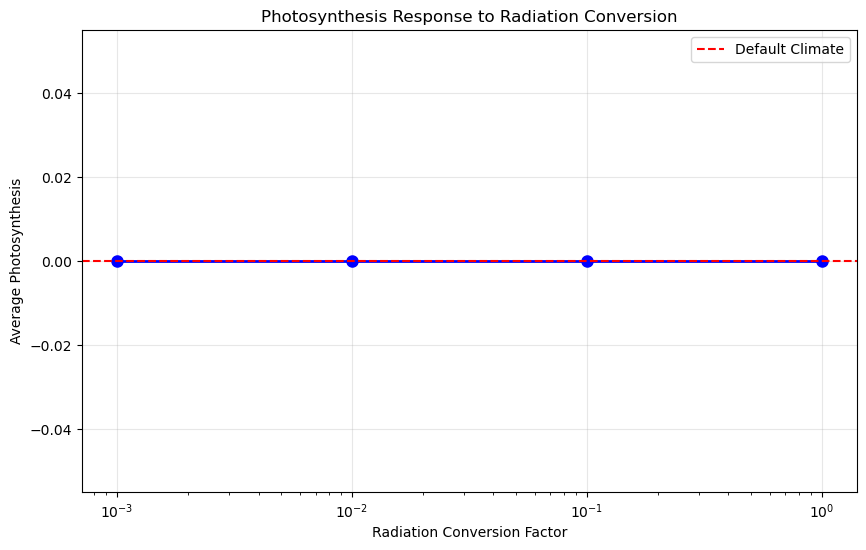

In [11]:
def analyze_results(ds_default, paleo_results):
    """Analyze the climate comparison results"""
    
    print("\n" + "="*60)
    print("📊 COMPARISON RESULTS")
    print("="*60)
    
    # Default climate stats
    default_rad = ds_default.environment__GR_day.mean().values
    default_photo = ds_default.photosynthesis__photo.mean().values
    
    print(f"\n📍 DEFAULT CLIMATE:")
    print(f"   Average Radiation: {default_rad:.1f} J/cm²/h")
    print(f"   Average Photosynthesis: {default_photo:.3f}")
    
    print(f"\n📍 PALEO CLIMATE RESULTS:")
    print("   Factor | Radiation | Photosynthesis | Status")
    print("   " + "-" * 50)
    
    best_factor = None
    best_photo_diff = float('inf')
    
    for factor, rad, photo in paleo_results:
        photo_diff = abs(photo - default_photo)
        status = "✅ GOOD" if 0.5 <= photo/default_photo <= 2.0 else "❌ NEEDS ADJUSTMENT"
        
        print(f"   {factor:6.3f} | {rad:8.1f}   | {photo:13.3f}  | {status}")
        
        if photo_diff < best_photo_diff and photo > 0:
            best_photo_diff = photo_diff
            best_factor = factor
    
    if best_factor:
        print(f"\n💡 RECOMMENDATION: Use radiation_conversion_factor = {best_factor}")
    
    # Plot comparison
    import matplotlib.pyplot as plt
    
    factors = [r[0] for r in paleo_results]
    photos = [r[2] for r in paleo_results]
    
    plt.figure(figsize=(10, 6))
    plt.plot(factors, photos, 'bo-', linewidth=2, markersize=8)
    plt.axhline(y=default_photo, color='r', linestyle='--', label='Default Climate')
    plt.xscale('log')
    plt.xlabel('Radiation Conversion Factor')
    plt.ylabel('Average Photosynthesis')
    plt.title('Photosynthesis Response to Radiation Conversion')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

# Analyze the results
analyze_results(ds_default, paleo_results)

En este caso debemos analizar a detalle la forma en que se procesa el clima
El coeficiente dentro de la fotosintesis no reacciona de forma adecuada
Ademas parece que el '.csv' del Paleo-Clima no cuenta con el formato o los datos correctos

Se confirma que se pueden modificar los modulos para
lograr un debugg y ademas un comportamiento "Custom"

! DESPUES DEL ENVIRONMENT SE MODIFICARA Phenology,Topology,Geometry o Photosintesis

--------------------

# Plotear variables

## Plot the 'fructose' content for a few GUs

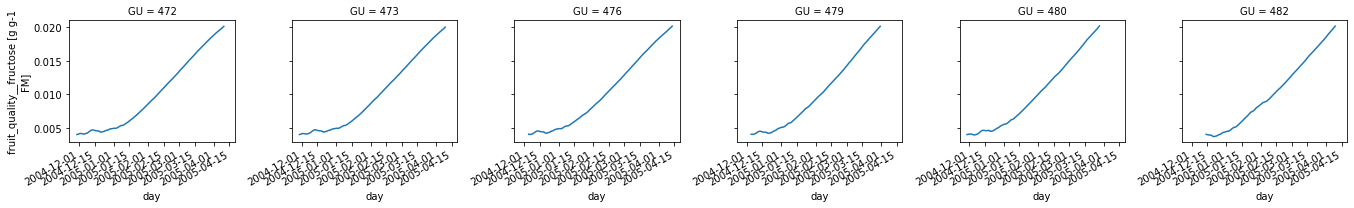

In [6]:
ds.fruit_quality__fructose.where(ds.phenology__nb_fruit > 0, drop=True)[:, 0:6].plot(col='GU', col_wrap=6)